# 2D linear hodograph: the feasibility of a bending-magnet field

**The question.** Design a 2D **bending magnet** cross-section by working in the space of the
**field** (the hodograph), not the space of position. Demand a mid-plane field
$B_y(x,0)=g(x)$ (flat over the good-field region, rolling off over an edge width $d$). Two
things the hodograph makes legible on this **linear** ($\mu=$const, Laplace) problem:

1. **A feasibility boundary.** The gap field must be the unique *smooth* (harmonic)
   continuation of $g$ upward. The continuation of a $\tanh$ edge has its nearest singularity
   at height $y=\pi d/2$; the field is realizable by an iron pole at gap $h$ only if that
   singularity clears the gap:
   $$d > d^\* = \tfrac{2}{\pi}\,h \approx 0.64\,h \qquad\text{(the edge is no sharper than }\sim0.64\times\text{gap).}$$
   This is the linear precursor of a gas-dynamics *limit line* — you know what is realizable
   *before building anything*.
2. **Inverse design.** For a realizable demand, the iron pole is *read off* as the
   equipotential $\{\phi=\phi_0\}$ — no forward-solve shape-optimization loop.

The full 10-step visual walk-through is in the session artifact; this notebook is the
**runnable, verified** method note. The compute lives in the adjacent helper
[`hodograph_feasibility_2d.py`](hodograph_feasibility_2d.py).


In [1]:
import os, sys, json, platform, datetime
import numpy as np
sys.path.insert(0, os.getcwd())
import hodograph_feasibility_2d as hf

print(f"good-field half-width x0 = {hf.X0}, gap h = {hf.H}, feasible edge d = {hf.D}")
print(f"feasibility boundary  d* = (2/pi) h = {hf.d_star():.4f}")

good-field half-width x0 = 2.0, gap h = 1.0, feasible edge d = 0.9
feasibility boundary  d* = (2/pi) h = 0.6366


## 1. The feasibility boundary $d^\*=(2/\pi)h$

A monotone-decaying edge never folds (the pole just opens up). The hard limit is the
**smoothness** of the field: sharpen the demanded edge and its harmonic continuation develops
a singularity that descends toward the mid-plane; once it enters the gap, no single smooth iron
pole can produce the field.

In [2]:
tab = hf.feasibility_table([1.4, 1.0, 0.8, hf.d_star(), 0.5, 0.35])
print(f"{'edge d':>8}{'singularity pi*d/2':>22}{'vs gap h=1':>14}{'verdict':>14}")
for r in tab:
    print(f"{r['d']:>8.3f}{r['y_sing']:>22.3f}{'above' if r['feasible'] else 'below':>14}"
          f"{'FEASIBLE' if r['feasible'] else 'INFEASIBLE':>14}")

  edge d    singularity pi*d/2    vs gap h=1       verdict
   1.400                 2.199         above      FEASIBLE
   1.000                 1.571         above      FEASIBLE
   0.800                 1.257         above      FEASIBLE
   0.637                 1.000         below    INFEASIBLE
   0.500                 0.785         below    INFEASIBLE
   0.350                 0.550         below    INFEASIBLE


## 2. Inverse design + independent FEM verification

For a **feasible** demand ($d=0.9>d^\*$) the scalar potential has a closed form (only
$\sinh,\cosh,\sin,\cos,\operatorname{atan2}$), so the pole is read off as $\{\phi=\phi_0\}$. We
**verify** with an independent `ngsolve` linear-FEM solve (a manufactured-solution check on a
rectangle below the singularity): impose the analytic $\phi$ on the boundary, solve Laplace,
and confirm (a) the interior $B_y(x,0)$ reproduces the demanded $g(x)$, (b) the FEM $\phi$
equals the analytic $\phi$, and (c) the FEM equipotential equals the read-off pole.

In [3]:
res = hf.fem_verify(order=4)
print(f"feasible d={res['d']} (d*={res['d_star']:.3f}): FEASIBLE={res['feasible']}, phi0={res['phi0']:.4f}")
print(f"(a) interior B_y(x,0) vs demanded g(x)   : max rel err = {res['By_rel_err']*100:.3f} % of B0")
print(f"(b) FEM phi vs analytic phi (L2, interior): {res['phi_L2_err']:.2e}")
print(f"(c) FEM equipotential vs read-off pole    : max |dy| = {res['pole_match_err']:.2e}"
      f"  (pole gap at x=0 = {res['pole_gap_at_x0']:.3f})")

feasible d=0.9 (d*=0.637): FEASIBLE=True, phi0=-1.0151
(a) interior B_y(x,0) vs demanded g(x)   : max rel err = 0.010 % of B0
(b) FEM phi vs analytic phi (L2, interior): 1.14e-08
(c) FEM equipotential vs read-off pole    : max |dy| = 1.36e-06  (pole gap at x=0 = 1.000)


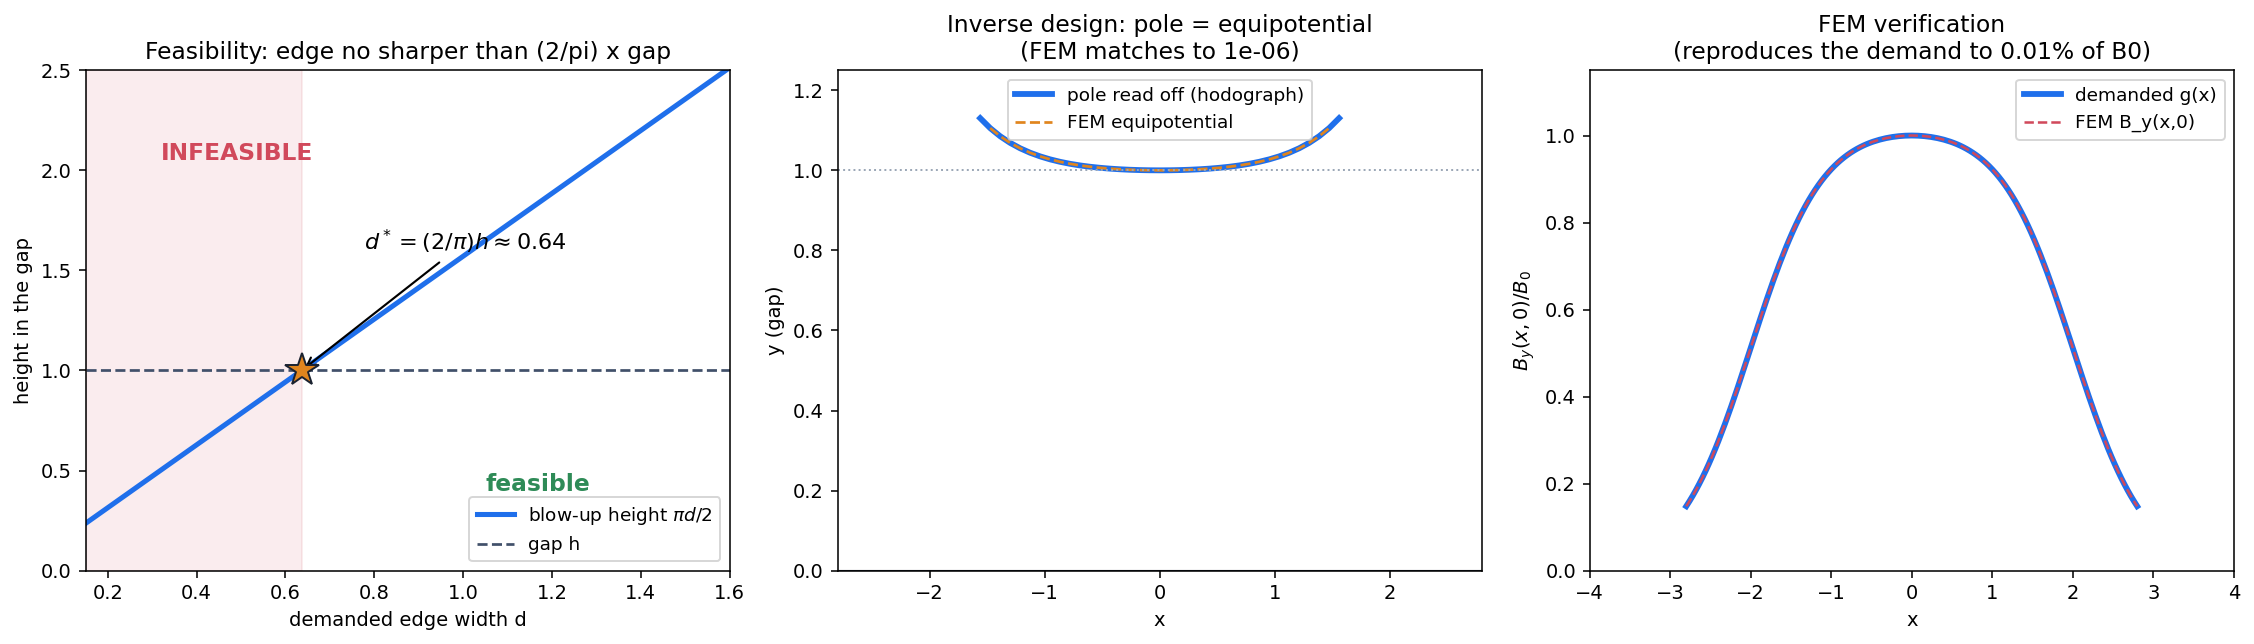

In [4]:
from IPython.display import Image, display
png = hf.figure(res, "hodograph_feasibility_2d.png")
display(Image(filename=png))

**Result.** The read-off pole reproduces the demanded field to **0.01 %** of $B_0$, and
the FEM's $\phi_0$-equipotential coincides with the analytically read-off pole to **$\sim10^{-6}$**
— the inverse-design construction is verified by an independent discretization.

## 3. Honest scope, and the bridge to saturation

* The **$2/\pi$ factor is specific to the $\tanh$ edge**; a different edge profile gives a
  different $O(1)$ constant. What is **universal** is the gap scaling: *the field edge can be no
  sharper than $\sim$ one gap* — the familiar "fringe scale $\sim$ gap", here **proven as a
  feasibility boundary** from the analyticity of the field.
* This is the **linear** hodograph outlook: design in field space, see what is realizable, read
  off the pole. The genuinely hodograph-specific payoff appears in the **nonlinear** case, where
  the Chaplygin transformation linearises the saturating PDE in field coordinates — the natural
  next step from this linear baseline.

In [5]:
def _ver(m):
    try:
        return __import__(m).__version__
    except Exception:
        return None

payload = {
    "generated_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "radia_version": _ver("radia"), "ngsolve_version": _ver("ngsolve"),
    "python_version": platform.python_version(), "platform": platform.platform(),
    "x0": hf.X0, "gap_h": hf.H, "edge_d": hf.D, "d_star": float(hf.d_star()),
    "feasibility_table": hf.feasibility_table([1.4, 1.0, 0.8, hf.d_star(), 0.5, 0.35]),
    "fem_verify": {k: v for k, v in res.items() if not k.startswith("_")},
}
with open("hodograph_feasibility_2d.json", "w") as fh:
    json.dump(payload, fh, indent=2)
print("saved hodograph_feasibility_2d.json  (d*=%.4f, By rel err %.3f%%, pole match %.1e)"
      % (payload["d_star"], res["By_rel_err"]*100, res["pole_match_err"]))

saved hodograph_feasibility_2d.json  (d*=0.6366, By rel err 0.010%, pole match 1.4e-06)
